This workbook implements a form of generalised profiling: Logistic growth with ecological data from https://doi.org/10.1016/j.jtbi.2021.110998 

Matthew J Simpson - QUT

Ruth E Baker - Oxford

December 2025

In [44]:
using Plots, DifferentialEquations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Statistics
using SparseArrays, StatsAPI, LinearAlgebra
gr(); #Load packages 

In [45]:
Tend = 4028;
t=[0, 769, 1140, 1488, 1876, 2233, 2602, 2889, 3213, 3621, 4028]; #Data collection times
data = [2.352254642,4.396074415,8.434146341,22.25079365,38.9,59.04803013,67.84648814,69.51641791,74.09765494,82.29230769,80.88291457]; #Data 

tf=LinRange(0,Tend,4028); #Discretised time variable, fine discretisation for ODE enforcing
Kt = 80; λt = 0.002; u0=2.3; σt = 2.0; #Parameter estimates
ue(t) = K*u0/(u0+(K-u0)*exp(-λ*t)); #exact solution

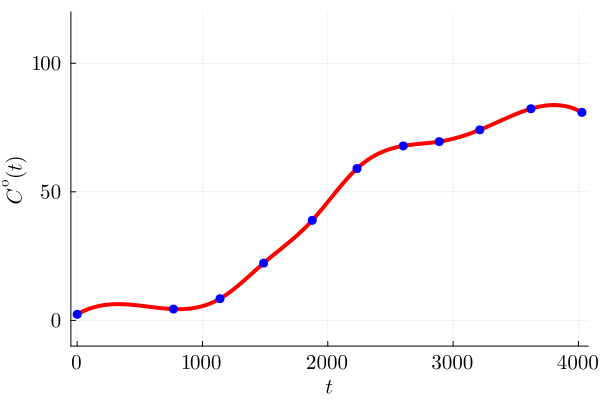

In [46]:
S_interp = interpolate(t, data, BSplineOrder(4)) #Create spline to overfit the data
B = basis(S_interp);                             #Basis functions
Coeff = coefficients(S_interp)                   #Spline coefficients

Csp = collocation_matrix(B, t, Derivative(0), SparseMatrixCSC{Float64, Int});      #Collocation matrix for the function on the coarse grid
Cspf = collocation_matrix(B, tf, Derivative(0), SparseMatrixCSC{Float64, Int});    #Collocation matrix for the function on the fine grid
C1spf = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int});   #Collocation matrix for the first derivative on the fine grid

C  = Csp*Coeff;    #Evaluate spline for the function on the coarse grid
Cf  = Cspf*Coeff   #Evaluate spline for the function on the fine grid
dCf = C1spf*Coeff  #Evaluate spline for the first derivative on the fine grid

p1 = plot(tf,Cf,lw=4,lc=:red,label=false) #Plot results
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)
#savefig("f6a.svg")

In [47]:
function loglhood(data,C,Cf,dCf,t,tf,w,a)  #Function to evaluate the loglikelihood of the data stored in the vector data. 
    
ℓ =0; ℓd =0; ℓm =0;    
dist=Normal(0,a[3]) 
ℓd+=loglikelihood(dist,data-C)  
ℓm = sum((dCf .- a[1] .*Cf .*(1.0 .- Cf/a[2])  ).^2) / length(tf) 
ℓ = w[1]*ℓd - w[2]*ℓm;
return ℓ

end;

In [48]:
function Optimise(fun,θ₀,lb,ub) # Optimize finds the values of parameters \theta that maximise the objective function fun with lower bounds lb, and upper bounds ub
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = optimize(opt,θ₀)
    return res[[2,1]]
end

Optimise (generic function with 1 method)

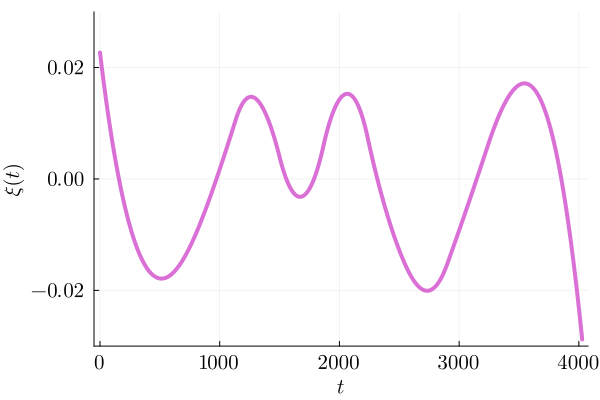

In [49]:
λmin=0.0005; λmax=0.02;  Kmin=80; Kmax=120; σmin = 0.1; σmax=5;  #Lower/upper bounds
θG=[λt, Kt, σt] #Iniitial estimate of the parameter values
lb=[λmin,Kmin,σmin]
ub=[λmax,Kmax,σmax]
a = zeros(3);
w = [1,1];
funopt(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ1,fopt)=Optimise(funopt,θG,lb,ub) #Call to NLopt to provide the first estimate of the parameters 
a1 = plot(tf,dCf - θ1[1]*Cf.*(1.0 .- Cf/θ1[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

Iteration 2

In [50]:
ℓd=0; ℓm =0
ℓd+=loglikelihood(Normal(0,θ1[3]) ,data-C);
ℓm = sum((dCf .- θ1[1].*Cf.*(1.0 .- Cf/θ1[2])).^2) / length(tf);
w = [1.0,abs(1/ℓm)];
funopt2(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ2,fopt)=Optimise(funopt2,θG,lb,ub) #Call to NLopt 

([0.002298830166114772, 81.48988154796302, 0.1], 14.220112157685517)

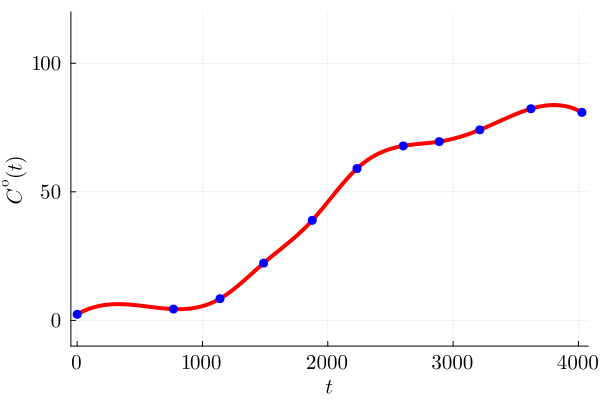

In [51]:
d0=data; d1=zeros(length(tf));
d1 = [θ2[1]*Cf[i]*(1.0 - Cf[i]/θ2[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [52]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ2[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ2[1].*Cf.*(1.0 .- Cf/θ2[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 5136.302666747236
Model distance 2.811025689239509e-5


Iteration 3

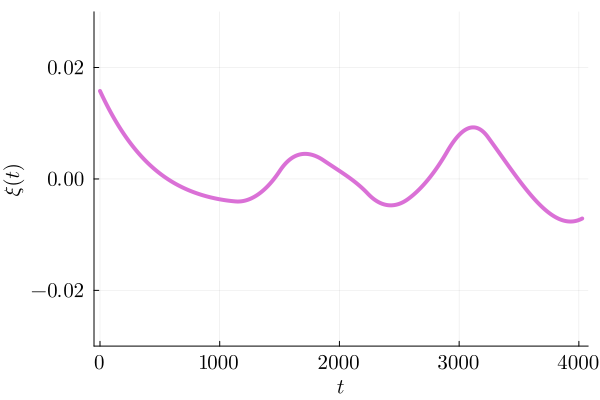

In [53]:
funopt3(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ3,fopt)=Optimise(funopt3,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ3[1]*Cf.*(1.0 .- Cf/θ3[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

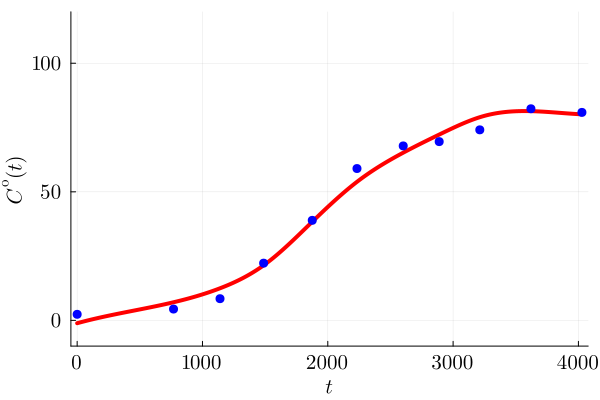

In [54]:
d0=data; d1=zeros(length(tf));
d1 = [θ3[1]*Cf[i]*(1.0 - Cf[i]/θ3[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [55]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ3[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ3[1].*Cf.*(1.0 .- Cf/θ3[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 27.46633533026526
Model distance 5.064315636994103e-6


Iteration 4

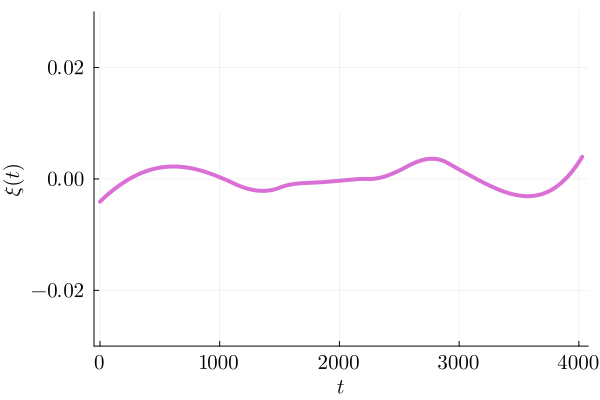

In [56]:
funopt4(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ4,fopt)=Optimise(funopt4,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ4[1]*Cf.*(1.0 .- Cf/θ4[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

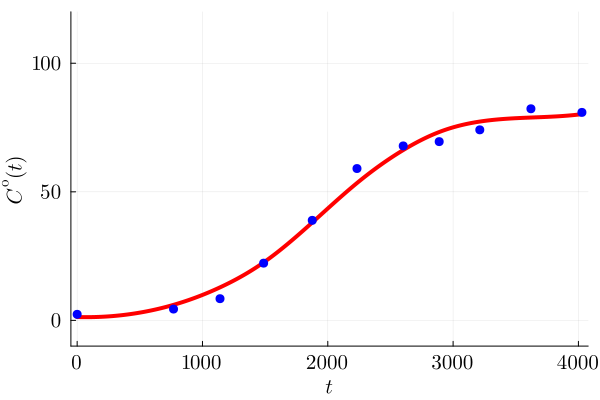

In [57]:
d0=data; d1=zeros(length(tf));
d1 = [θ4[1]*Cf[i]*(1.0 - Cf[i]/θ4[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [58]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ4[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ4[1].*Cf.*(1.0 .- Cf/θ4[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 26.102413782396255
Model distance 7.357940461227358e-7


Iteration 5

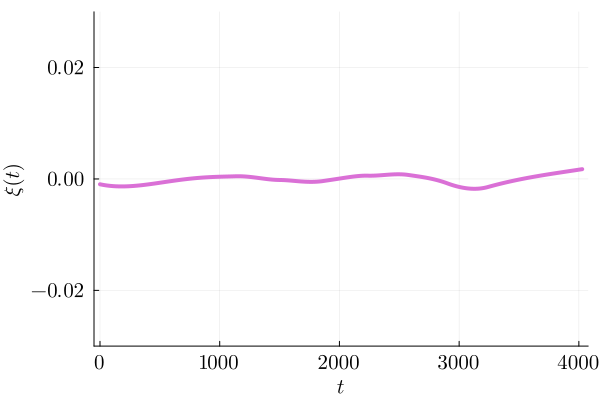

In [59]:
funopt5(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ5,fopt)=Optimise(funopt5,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ5[1]*Cf.*(1.0 .- Cf/θ5[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

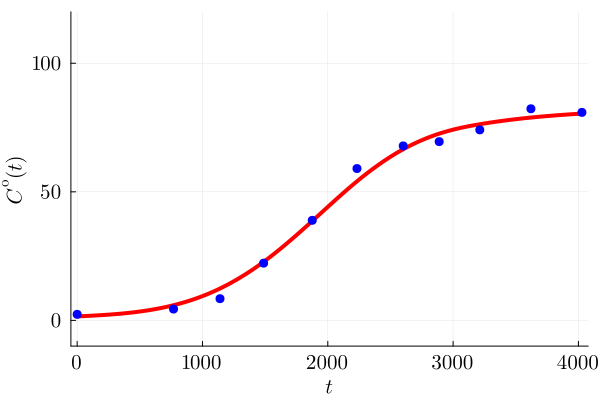

In [60]:
d0=data; d1=zeros(length(tf));
d1 = [θ5[1]*Cf[i]*(1.0 - Cf[i]/θ5[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [61]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ5[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ5[1].*Cf.*(1.0 .- Cf/θ5[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 25.802236720832937
Model distance 1.8965055905326998e-7


Iteration 6

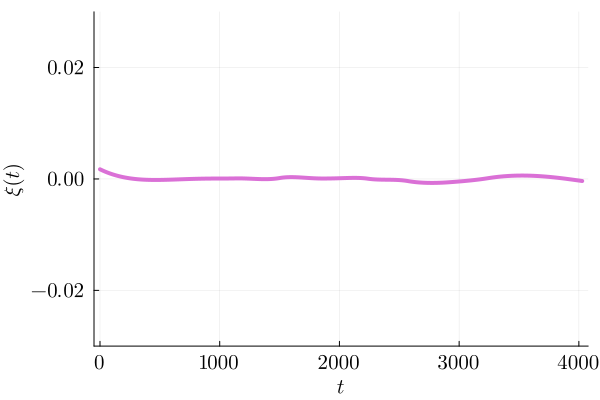

In [62]:
funopt6(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ6,fopt)=Optimise(funopt6,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ6[1]*Cf.*(1.0 .- Cf/θ6[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

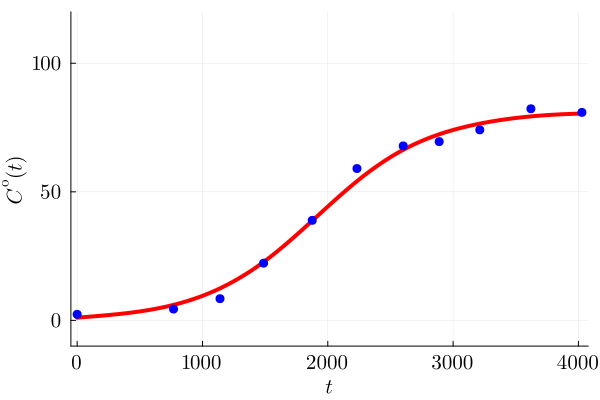

In [63]:
d0=data; d1=zeros(length(tf));
d1 = [θ6[1]*Cf[i]*(1.0 - Cf[i]/θ6[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [64]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ6[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ6[1].*Cf.*(1.0 .- Cf/θ6[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 26.03253357262984
Model distance 3.394711648461963e-8


Iteration 7

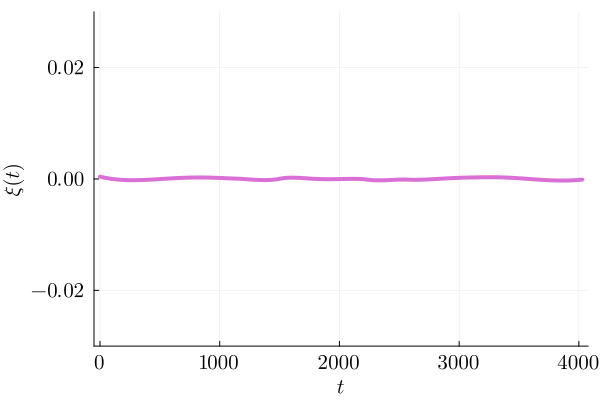

In [65]:
funopt7(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ7,fopt)=Optimise(funopt7,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ7[1]*Cf.*(1.0 .- Cf/θ7[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

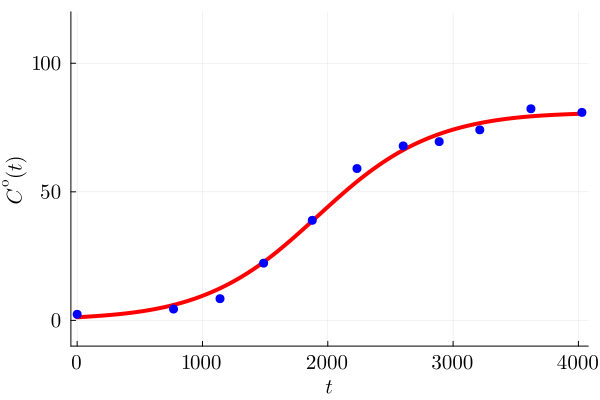

In [66]:
d0=data; d1=zeros(length(tf));
d1 = [θ7[1]*Cf[i]*(1.0 - Cf[i]/θ7[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [67]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ7[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ7[1].*Cf.*(1.0 .- Cf/θ7[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 26.082511099081504
Model distance 1.9996375381272465e-8


Iteration 8

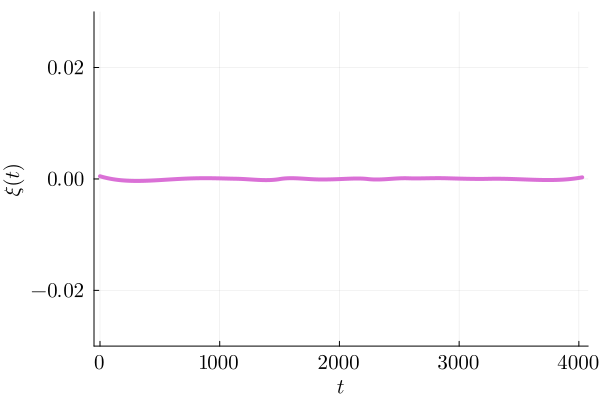

In [68]:
funopt8(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ8,fopt)=Optimise(funopt8,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ8[1]*Cf.*(1.0 .- Cf/θ8[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

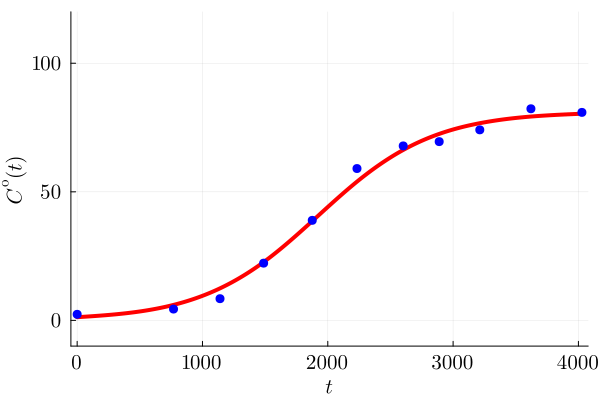

In [69]:
d0=data; d1=zeros(length(tf));
d1 = [θ8[1]*Cf[i]*(1.0 - Cf[i]/θ8[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)

In [70]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ8[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ8[1].*Cf.*(1.0 .- Cf/θ8[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 26.06141097626397
Model distance 1.555139566354167e-8


Itation 9

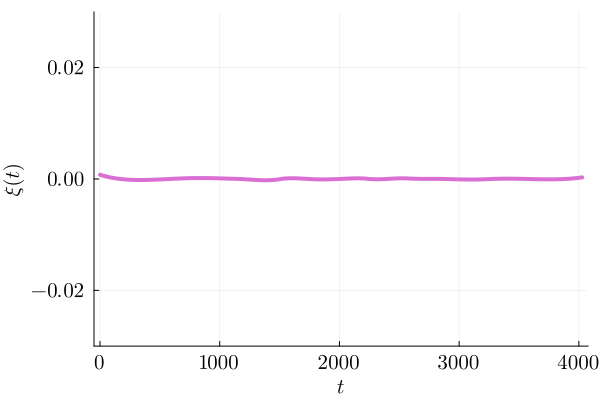

In [71]:
funopt9(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ9,fopt)=Optimise(funopt9,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ9[1]*Cf.*(1.0 .- Cf/θ9[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

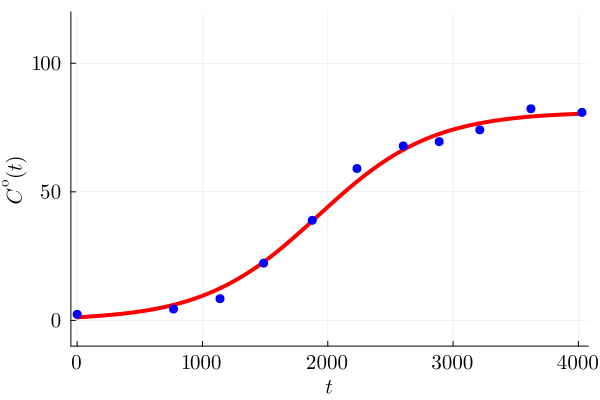

In [72]:
d0=data; d1=zeros(length(tf));
d1 = [θ9[1]*Cf[i]*(1.0 - Cf[i]/θ9[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)
#savefig("f6b.svg")

In [73]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ9[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ9[1].*Cf.*(1.0 .- Cf/θ9[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 26.035064456738326
Model distance 1.3867618104405671e-8


Iteration 10

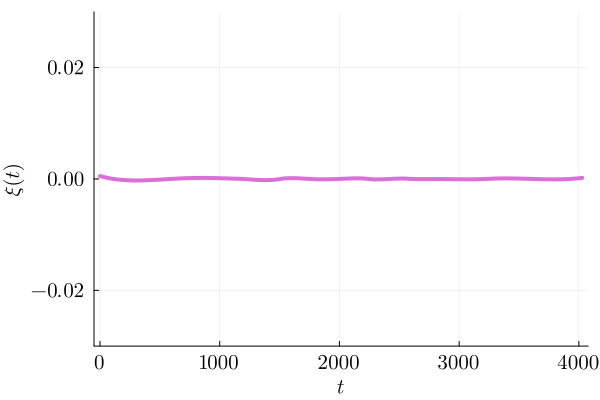

In [74]:
funopt10(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ10,fopt)=Optimise(funopt10,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ10[1]*Cf.*(1.0 .- Cf/θ10[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-50,t[end]+50),ylims=(-0.03,0.03),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([-0.02,0.00,0.02],[L"-0.02", L"0.00", L"0.02"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

In [75]:
ue(t) = θ10[2]*Cf[1]/(Cf[1]+(θ10[2]-Cf[1])*exp(-θ10[1]*t))

ue (generic function with 1 method)

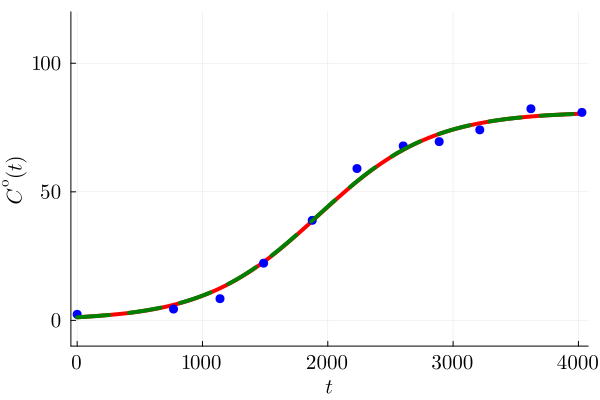

In [76]:
p1 = plot(tf,Cf; lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-50,t[end]+50), ylims=(-10,120),xticks = ([0,1000,2000,3000,4000],[L"0", L"1000", L"2000", L"3000", L"4000"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
p1=plot!(ue,0,Tend,lw=4,lc=:green,ls=:dash,legend=false)
display(p1)

In [77]:
θ1

3-element Vector{Float64}:
  0.0022988290560620457
 81.48989745949861
  0.1

In [78]:
θ6

3-element Vector{Float64}:
  0.00219098620099976
 81.15755113658923
  2.525984358345991

In [79]:
θ10

3-element Vector{Float64}:
  0.002189359769374072
 81.18651733469213
  2.580233113121357

In [80]:
Cf[1]

1.2037818089814323